In [1]:
# Install kaggle
!pip install -q kaggle

# Download dataset directly
!kaggle datasets download -d shivamb/netflix-shows --force

# Unzip it
!unzip -o netflix-shows.zip

# Now load it
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ All libraries ready!")
df = pd.read_csv("netflix_titles.csv")
print(f"✅ Dataset loaded! Shape: {df.shape}")
print(df.head(3))

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
100% 1.34M/1.34M [00:00<00:00, 143MB/s]

Archive:  netflix-shows.zip
  inflating: netflix_titles.csv      
✅ All libraries ready!
✅ Dataset loaded! Shape: (8807, 12)
  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water              NaN   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021          2021  TV-MA   1

In [2]:
# Download directly from GitHub mirror (no Kaggle needed)
!wget -q "https://raw.githubusercontent.com/dsrscientist/dataset1/master/netflix_titles.csv"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ All libraries ready!")
df = pd.read_csv("netflix_titles.csv")
print(f"✅ Dataset loaded! Shape: {df.shape}")
print(df.head(3))

✅ All libraries ready!
✅ Dataset loaded! Shape: (8807, 12)
  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water              NaN   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021          2021  TV-MA   1 Season   

                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas, TV Mysteries   
2  Crime TV Sh

In [3]:
# Shape of dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
df.head()

Rows: 8807, Columns: 12

--- Column Names ---
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

--- Data Types ---
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

--- First 5 Rows ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Check missing values
null_counts = df.isnull().sum()
null_ratio = (df.isnull().sum() / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_ratio
}).sort_values('Missing %', ascending=False)

print(null_df)

              Missing Count  Missing %
director               2634      29.91
country                 831       9.44
cast                    825       9.37
date_added               10       0.11
rating                    4       0.05
duration                  3       0.03
show_id                   0       0.00
type                      0       0.00
title                     0       0.00
release_year              0       0.00
listed_in                 0       0.00
description               0       0.00


/tmp/ipykernel_1855/3156818987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_df.index, y=null_df['Missing %'], palette='Reds_r')


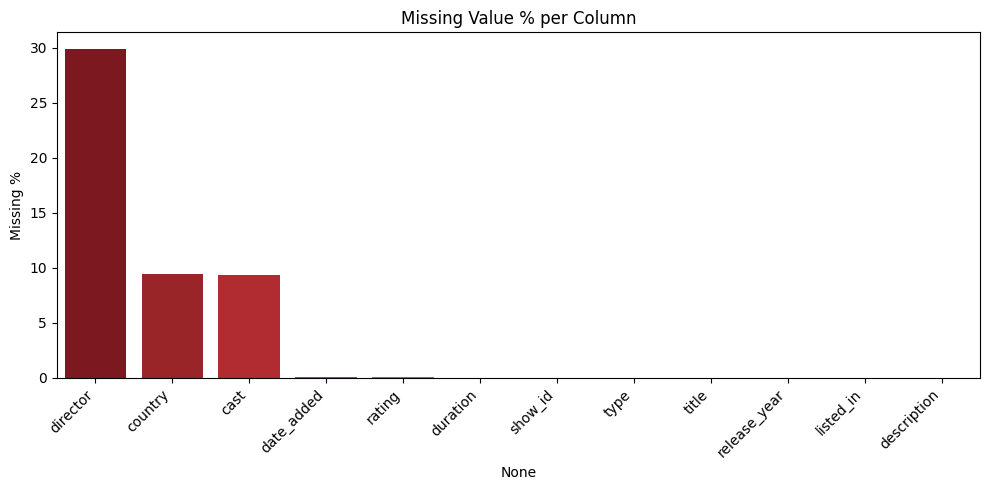

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(x=null_df.index, y=null_df['Missing %'], palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title('Missing Value % per Column')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

In [6]:
# Content type split (Movie vs TV Show)
print("--- Content Type Distribution ---")
print(df['type'].value_counts())
print()

# Rating distribution
print("--- Rating Distribution ---")
print(df['rating'].value_counts())

--- Content Type Distribution ---
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

--- Rating Distribution ---
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [7]:
# Fill missing values with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

# Drop rows where date_added or description is missing (very few)
df.dropna(subset=['date_added', 'description'], inplace=True)

print(f"✅ Cleaned! Remaining rows: {len(df)}")
print(df.isnull().sum())

✅ Cleaned! Remaining rows: 8797
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


/tmp/ipykernel_1855/85193974.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1855/85193974.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [8]:
# Clean and convert date_added to datetime
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year and month as separate columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("✅ Date columns created!")
print(df[['date_added', 'year_added', 'month_added']].head())

✅ Date columns created!
  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


In [9]:
# Split duration into number and unit
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')

print("✅ Duration split done!")
print(df[['duration', 'duration_value', 'duration_unit']].head(10))

✅ Duration split done!
    duration  duration_value duration_unit
0     90 min            90.0           min
1  2 Seasons             2.0       Seasons
2   1 Season             1.0        Season
3   1 Season             1.0        Season
4  2 Seasons             2.0       Seasons
5   1 Season             1.0        Season
6     91 min            91.0           min
7    125 min           125.0           min
8  9 Seasons             9.0       Seasons
9    104 min           104.0           min


In [10]:
# Split the listed_in column (genres) by comma and explode
df['genre'] = df['listed_in'].str.split(',')
df_genres = df.explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()

print(f"✅ Exploded! Original rows: {len(df)} → Exploded rows: {len(df_genres)}")
print(df_genres['genre'].value_counts().head(10))

✅ Exploded! Original rows: 8797 → Exploded rows: 19303
genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


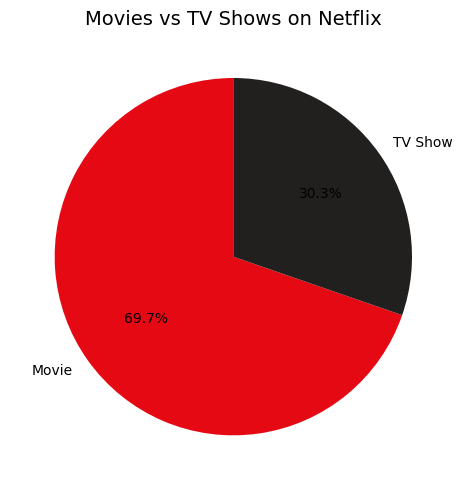

In [11]:
plt.figure(figsize=(7, 5))
colors = ['#E50914', '#221F1F']
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Movies vs TV Shows on Netflix', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1855/4073054536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


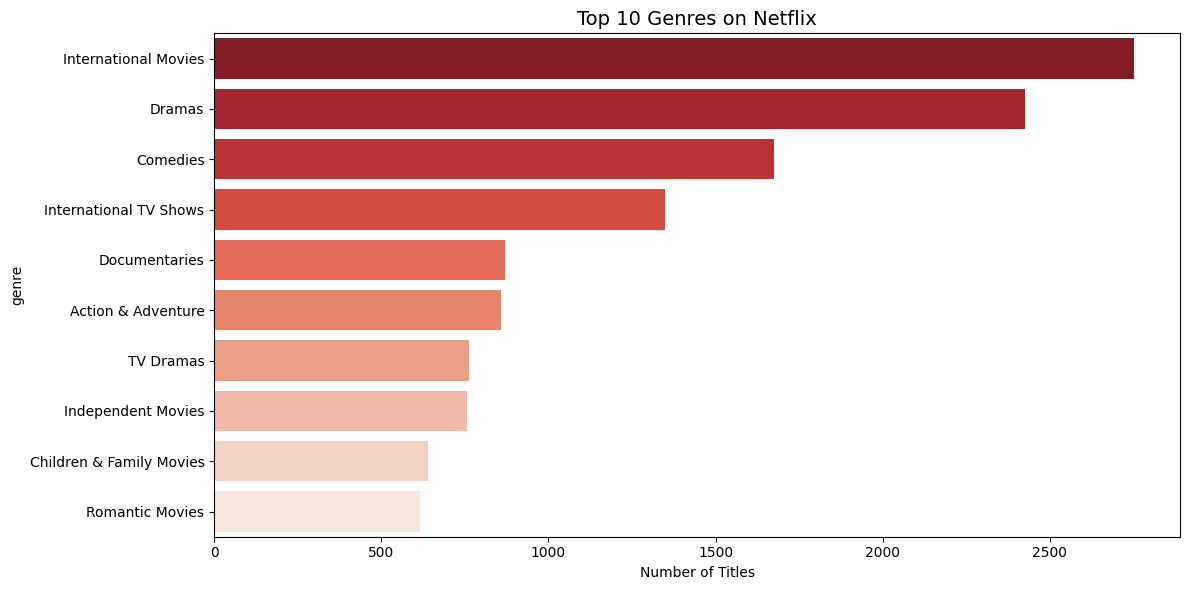

In [12]:
plt.figure(figsize=(12, 6))
top_genres = df_genres['genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

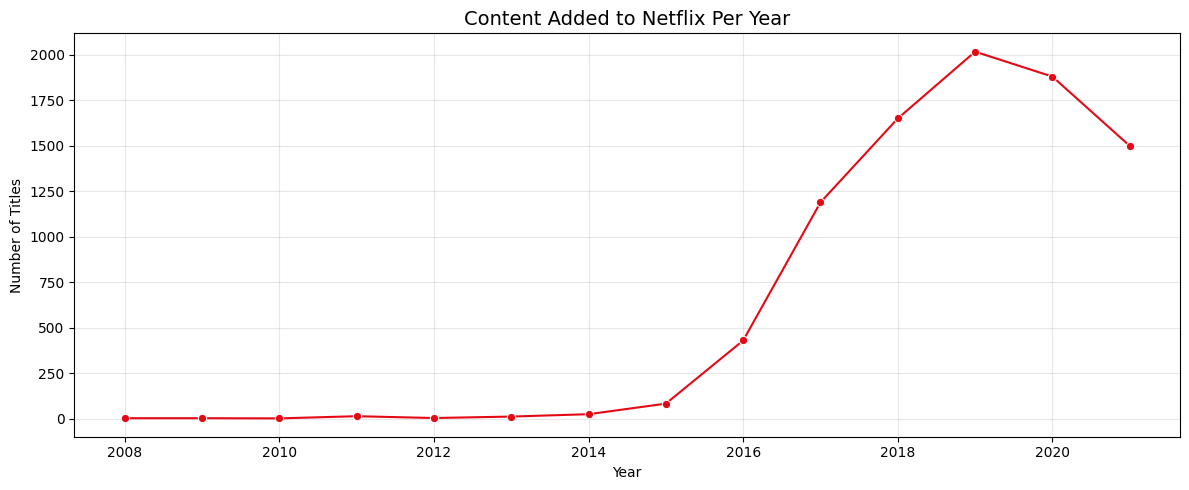

In [13]:
plt.figure(figsize=(12, 5))
yearly = df['year_added'].value_counts().sort_index()
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='#E50914')
plt.title('Content Added to Netflix Per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1855/1903871481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


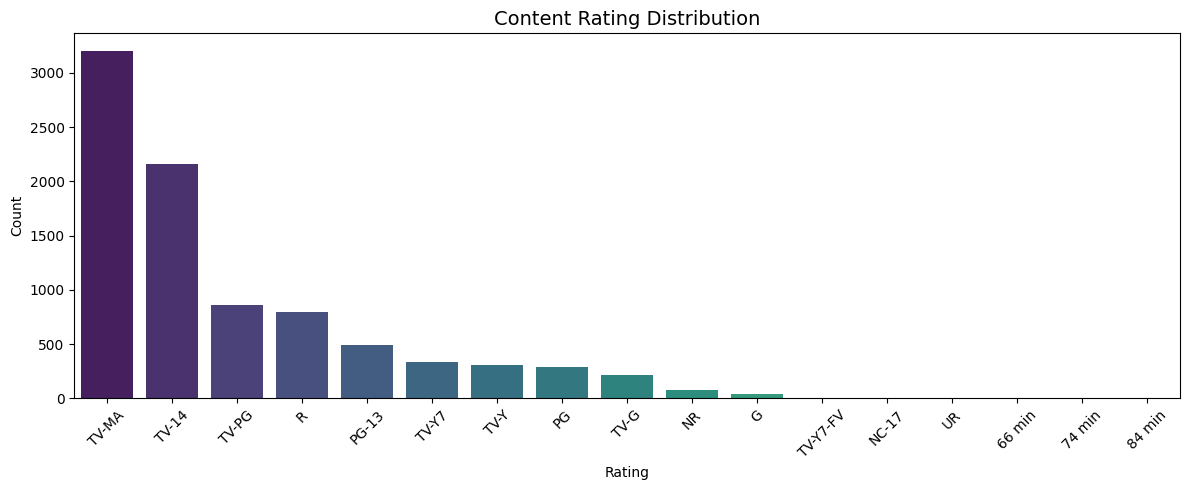

In [16]:
plt.figure(figsize=(12, 5))
rating_counts = df['rating'].value_counts()
rating_counts = rating_counts[rating_counts.index != 'Unknown']
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Content Rating Distribution', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

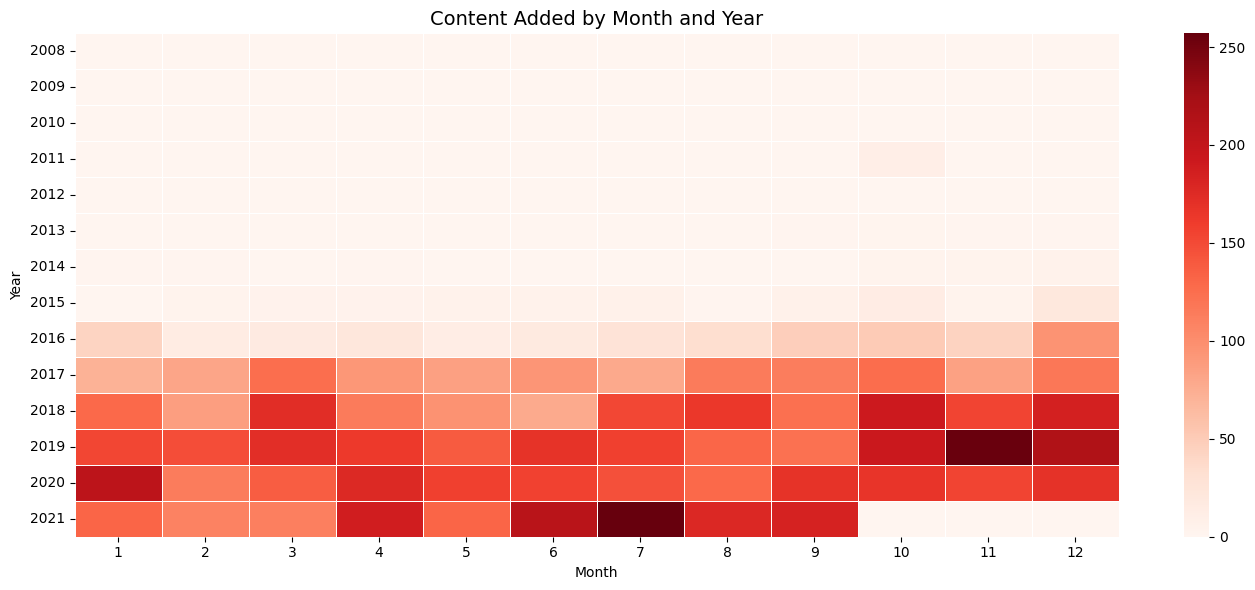

In [18]:
plt.figure(figsize=(14, 6))
pivot = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
sns.heatmap(pivot, cmap='Reds', linewidths=0.5)
plt.title('Content Added by Month and Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Fill any remaining nulls in description
df['description'] = df['description'].fillna('')

# Build TF-IDF matrix on descriptions
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['description'])

print(f"✅ TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Each title is represented as a vector of {tfidf_matrix.shape[1]} features")

✅ TF-IDF Matrix Shape: (8797, 5000)
Each title is represented as a vector of 5000 features


In [20]:
# Reset index for clean mapping
df_reset = df.reset_index(drop=True)

# Create title to index mapping
title_to_idx = pd.Series(df_reset.index, index=df_reset['title'].str.lower())

def get_similar_titles(title, top_n=5):
    title = title.lower()

    # Check if title exists
    if title not in title_to_idx:
        print(f"❌ Title '{title}' not found in dataset!")
        return

    # Get index of the title
    idx = title_to_idx[title]

    # Compute cosine similarity with all other titles
    cosine_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Get top N similar titles (excluding itself)
    similar_indices = cosine_scores.argsort()[::-1][1:top_n+1]

    print(f"\n🎬 Top {top_n} titles similar to '{df_reset.iloc[idx]['title']}':\n")
    for i, sim_idx in enumerate(similar_indices):
        title_name = df_reset.iloc[sim_idx]['title']
        score = cosine_scores[sim_idx]
        content_type = df_reset.iloc[sim_idx]['type']
        genre = df_reset.iloc[sim_idx]['listed_in']
        print(f"{i+1}. {title_name} ({content_type})")
        print(f"   Similarity Score: {score:.4f}")
        print(f"   Genre: {genre}\n")

In [21]:
# Test with different titles
get_similar_titles("Inception", top_n=5)


🎬 Top 5 titles similar to 'Inception':

1. Dedh Ishqiya (Movie)
   Similarity Score: 0.2133
   Genre: Comedies, Dramas, International Movies

2. Big Dreams, Small Spaces (TV Show)
   Similarity Score: 0.1854
   Genre: British TV Shows, International TV Shows, Reality TV

3. Eyyvah Eyyvah 2 (Movie)
   Similarity Score: 0.1850
   Genre: Comedies, International Movies, Romantic Movies

4. Quigley Down Under (Movie)
   Similarity Score: 0.1782
   Genre: Action & Adventure

5. Violet Evergarden (TV Show)
   Similarity Score: 0.1680
   Genre: Anime Series, International TV Shows, Romantic TV Shows



In [22]:
get_similar_titles("Breaking Bad", top_n=5)


🎬 Top 5 titles similar to 'Breaking Bad':

1. Alexa & Katie (TV Show)
   Similarity Score: 0.2045
   Genre: Kids' TV, TV Comedies

2. Mariposa (Movie)
   Similarity Score: 0.1993
   Genre: Comedies, International Movies, Romantic Movies

3. Dismissed (Movie)
   Similarity Score: 0.1982
   Genre: Thrillers

4. Fireplace 4K: Crackling Birchwood from Fireplace for Your Home (Movie)
   Similarity Score: 0.1978
   Genre: Movies

5. Loving Annabelle (Movie)
   Similarity Score: 0.1931
   Genre: Dramas, Independent Movies, LGBTQ Movies



In [23]:
# See what words matter most for any title
def get_top_keywords(title, top_n=10):
    title = title.lower()
    if title not in title_to_idx:
        print(f"❌ Title not found!")
        return

    idx = title_to_idx[title]
    feature_names = tfidf.get_feature_names_out()
    tfidf_scores = tfidf_matrix[idx].toarray().flatten()

    top_indices = tfidf_scores.argsort()[::-1][:top_n]

    print(f"\n🔑 Top keywords for '{df_reset.iloc[idx]['title']}':")
    for i in top_indices:
        if tfidf_scores[i] > 0:
            print(f"  {feature_names[i]}: {tfidf_scores[i]:.4f}")

get_top_keywords("Inception")


🔑 Top keywords for 'Inception':
  plant: 0.3764
  idea: 0.3449
  target: 0.3174
  thief: 0.2976
  leading: 0.2881
  troubled: 0.2704
  dangerous: 0.2505
  secrets: 0.2487
  job: 0.2431
  dreams: 0.2427


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Create a clean copy for pipeline
df_pipe = df[['type', 'rating', 'duration_value', 'duration_unit', 'year_added', 'month_added']].copy()

# Separate numeric and categorical columns
numeric_features = ['duration_value', 'year_added', 'month_added']
categorical_features = ['type', 'rating', 'duration_unit']

print("✅ Features ready!")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"\nShape: {df_pipe.shape}")
df_pipe.head()

✅ Features ready!
Numeric features: ['duration_value', 'year_added', 'month_added']
Categorical features: ['type', 'rating', 'duration_unit']

Shape: (8797, 6)


,type,rating,duration_value,duration_unit,year_added,month_added
0,Movie,PG-13,90.0,min,2021,9
1,TV Show,TV-MA,2.0,Seasons,2021,9
2,TV Show,TV-MA,1.0,Season,2021,9
3,TV Show,TV-MA,1.0,Season,2021,9
4,TV Show,TV-MA,2.0,Seasons,2021,9


In [25]:
# Numeric pipeline — impute missing then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline — impute missing then encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("✅ Pipeline built successfully!")
print(preprocessor)

✅ Pipeline built successfully!
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['duration_value', 'year_added',
                                  'month_added']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['type', 'rating', 'duration_unit'])])


In [26]:
# Fit and transform the data
transformed = preprocessor.fit_transform(df_pipe)

print(f"✅ Pipeline applied!")
print(f"Original shape: {df_pipe.shape}")
print(f"Transformed shape: {transformed.shape}")
print(f"\nWhat happened:")
print(f"  - Numeric columns scaled to mean=0, std=1")
print(f"  - Categorical columns one-hot encoded")
print(f"  - Missing values auto-filled")

✅ Pipeline applied!
Original shape: (8797, 6)
Transformed shape: (8797, 27)

What happened:
  - Numeric columns scaled to mean=0, std=1
  - Categorical columns one-hot encoded
  - Missing values auto-filled


In [27]:
# Detect outliers in duration_value using IQR method
Q1 = df['duration_value'].quantile(0.25)
Q3 = df['duration_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['duration_value'] < lower_bound) | (df['duration_value'] > upper_bound)]

print(f"✅ IQR Outlier Detection Complete!")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Outliers found: {len(outliers)}")
print(f"\nSample outliers:")
print(outliers[['title', 'type', 'duration_value', 'duration_unit']].head(10))

✅ IQR Outlier Detection Complete!
Q1: 2.0, Q3: 106.0, IQR: 104.0
Lower bound: -154.0, Upper bound: 262.0
Outliers found: 2

Sample outliers:
                            title   type  duration_value duration_unit
717   Headspace: Unwind Your Mind  Movie           273.0           min
4253   Black Mirror: Bandersnatch  Movie           312.0           min


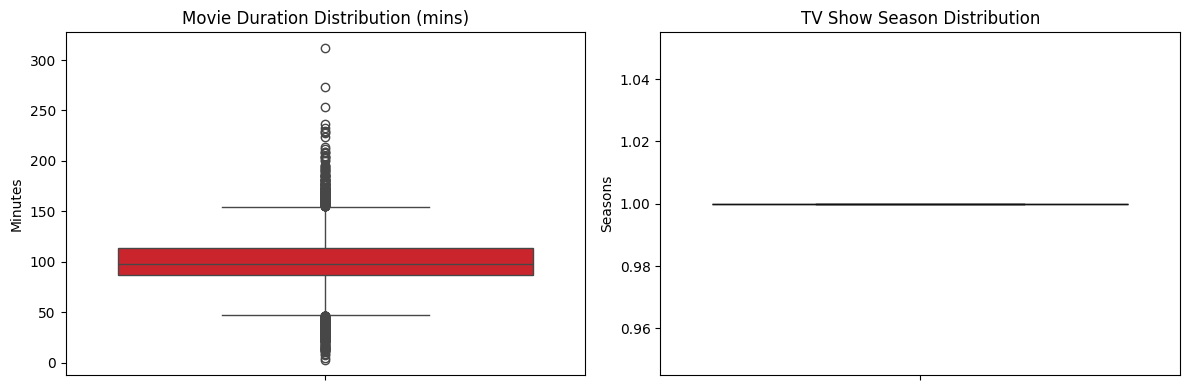

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
movies = df[df['duration_unit'] == 'min']['duration_value']
sns.boxplot(y=movies, color='#E50914')
plt.title('Movie Duration Distribution (mins)')
plt.ylabel('Minutes')

plt.subplot(1, 2, 2)
shows = df[df['duration_unit'] == 'Season']['duration_value']
sns.boxplot(y=shows, color='#221F1F')
plt.title('TV Show Season Distribution')
plt.ylabel('Seasons')

plt.tight_layout()
plt.show()

In [29]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 28.1 MB/s eta 0:00:00


In [30]:
%%writefile app.py

import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ─── Page Config ───────────────────────────────────────────
st.set_page_config(
    page_title="NetflixScope",
    page_icon="🎬",
    layout="wide"
)

# ─── Load Data ─────────────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv("netflix_titles.csv")
    df['director'].fillna('Unknown', inplace=True)
    df['cast'].fillna('Unknown', inplace=True)
    df['country'].fillna('Unknown', inplace=True)
    df['rating'].fillna('Unknown', inplace=True)
    df['duration'].fillna('Unknown', inplace=True)
    df.dropna(subset=['date_added', 'description'], inplace=True)
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
    df['year_added'] = df['date_added'].dt.year
    df['month_added'] = df['date_added'].dt.month
    df['genre'] = df['listed_in'].str.split(',')
    df = df.reset_index(drop=True)
    return df

df = load_data()

# ─── TF-IDF Setup ──────────────────────────────────────────
@st.cache_resource
def build_tfidf(df):
    tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
    matrix = tfidf.fit_transform(df['description'].fillna(''))
    return tfidf, matrix

tfidf, tfidf_matrix = build_tfidf(df)
title_to_idx = pd.Series(df.index, index=df['title'].str.lower())

# ─── Header ────────────────────────────────────────────────
st.markdown("""
    <h1 style='color:#E50914;'>🎬 NetflixScope</h1>
    <p style='color:gray;'>Content Analytics & Similarity Explorer</p>
    <hr>
""", unsafe_allow_html=True)

# ─── Sidebar Filters ───────────────────────────────────────
st.sidebar.header("🔎 Filter Content")

content_type = st.sidebar.multiselect(
    "Content Type",
    options=df['type'].unique().tolist(),
    default=df['type'].unique().tolist()
)

ratings = st.sidebar.multiselect(
    "Rating",
    options=sorted(df['rating'].unique().tolist()),
    default=[]
)

year_range = st.sidebar.slider(
    "Year Added",
    min_value=int(df['year_added'].min()),
    max_value=int(df['year_added'].max()),
    value=(2015, 2021)
)

# ─── Apply Filters ─────────────────────────────────────────
filtered = df[df['type'].isin(content_type)]
if ratings:
    filtered = filtered[filtered['rating'].isin(ratings)]
filtered = filtered[
    (filtered['year_added'] >= year_range[0]) &
    (filtered['year_added'] <= year_range[1])
]

# ─── Metrics Row ───────────────────────────────────────────
st.subheader("📊 Dataset Overview")
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Titles", len(filtered))
col2.metric("Movies", len(filtered[filtered['type'] == 'Movie']))
col3.metric("TV Shows", len(filtered[filtered['type'] == 'TV Show']))
col4.metric("Countries", filtered['country'].nunique())

st.markdown("---")

# ─── Filtered Data Table ───────────────────────────────────
st.subheader("📋 Filtered Titles")
st.dataframe(
    filtered[['title', 'type', 'listed_in', 'rating', 'year_added', 'country']].reset_index(drop=True),
    use_container_width=True,
    height=300
)

st.markdown("---")

# ─── Similarity Finder ─────────────────────────────────────
st.subheader("🤖 Content Similarity Finder")
search_title = st.text_input("Enter a Netflix title to find similar content:", placeholder="e.g. Inception, Breaking Bad")

if search_title:
    search_lower = search_title.lower()
    if search_lower in title_to_idx:
        idx = title_to_idx[search_lower]
        scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
        top_indices = scores.argsort()[::-1][1:6]

        st.success(f"Top 5 titles similar to **{df.iloc[idx]['title']}**")
        for rank, sim_idx in enumerate(top_indices):
            with st.expander(f"{rank+1}. {df.iloc[sim_idx]['title']} — Score: {scores[sim_idx]:.4f}"):
                st.write(f"**Type:** {df.iloc[sim_idx]['type']}")

Writing app.py


In [32]:
from google.colab import output
import subprocess, time, os

# Kill any existing streamlit
os.system("pkill -f streamlit")
time.sleep(2)

# Install localtunnel (no account needed)
os.system("npm install -g localtunnel")

# Start streamlit in background
process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(4)

# Create public URL using localtunnel
tunnel = subprocess.Popen(
    ["lt", "--port", "8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.DEVNULL
)
time.sleep(3)

url = tunnel.stdout.readline().decode("utf-8").strip()
print(f"✅ App is live at: {url}")
print("👆 Click the link → if it asks for a password, enter your Colab IP below")

# Get your IP for the password prompt
import requests
ip = requests.get("https://api.ipify.org").text
print(f"🔑 Your IP (use as tunnel password if asked): {ip}")

✅ App is live at: your url is: https://green-insects-eat.loca.lt
👆 Click the link → if it asks for a password, enter your Colab IP below
🔑 Your IP (use as tunnel password if asked): 35.243.162.218
